In [33]:
# %pip install -U langchain langchain-openai langchain-upstage langgraph langfuse faiss-cpu python-dotenv langchain-community langchain-teddynote

In [34]:
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain_upstage import ChatUpstage
from langchain_community.tools import TavilySearchResults
load_dotenv()

llm = ChatUpstage(model="solar-mini", temperature=0)
tools = [TavilySearchResults()]
web_search_agent = create_agent(model=llm, tools=tools)
frontend_expert = create_agent(model=llm, tools=tools)
backend_expert = create_agent(model=llm, tools=tools)

In [35]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages

class RecommendationState(TypedDict):
    current_node_type: str
    question: str
    context: str
    messages: Annotated[list, add_messages] # 대화 기록

class PlanNodeState(RecommendationState):
    parent_info: str

In [36]:
def parent_node_fetch(state: PlanNodeState) -> PlanNodeState:
    pass

In [37]:
def project_spec_fetch(state: PlanNodeState)->PlanNodeState:
    pass

In [38]:
def epic_node_process(state: PlanNodeState) -> PlanNodeState:
    pass

In [39]:
def story_node_process(state: PlanNodeState) -> PlanNodeState:
    pass

In [40]:
def task_node_process(state: PlanNodeState) -> PlanNodeState:
    pass

In [41]:
def sub_task_node_process(state: PlanNodeState) -> PlanNodeState:
    pass

In [42]:
def contributor_info_fetch(state: PlanNodeState) -> PlanNodeState:
    pass

In [43]:
def tech_stack_create(state: PlanNodeState) -> PlanNodeState:
    pass

In [44]:
def sub_task_tech_stack_create(state: PlanNodeState) -> PlanNodeState:
    pass

In [45]:
def structured_output_parser(state: PlanNodeState) -> PlanNodeState:
    pass

In [46]:
def sub_node_info_create(state: PlanNodeState) -> PlanNodeState:
    pass

In [47]:
def node_feedback(state: PlanNodeState) -> PlanNodeState:
    pass

In [48]:
def struct_feedback(state: PlanNodeState) -> PlanNodeState:
    pass

In [49]:
def tech_stack_integrator(state: PlanNodeState) -> PlanNodeState:
    pass

In [50]:
def sibiling_node_fetch(state: PlanNodeState) -> PlanNodeState:
    pass

In [51]:
from typing import Any

class ReturnNodeValue:
    # 초기화
    def __init__(self, node_secret: str):
        self._value = node_secret

    # 호출시 상태 업데이트
    def __call__(self, state: PlanNodeState) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}

In [52]:
def route_task(state: RecommendationState) -> str:
    if state["current_node_type"] == "TASK":
        return ["frontend_expert", "backend_expert"]
    elif state["current_node_type"] == "SUB_TASK":
        return "web_search_agent"

In [53]:
from langgraph.graph import StateGraph, END, START

recommend_graph_builder = StateGraph(RecommendationState)

recommend_graph_builder.add_node("frontend_expert", frontend_expert)
recommend_graph_builder.add_node("backend_expert", backend_expert)
recommend_graph_builder.add_node("web_search_agent", web_search_agent)
recommend_graph_builder.add_node("tech_stack_integrator", tech_stack_integrator)

recommend_graph_builder.add_conditional_edges(START, route_task,
                                              ["frontend_expert", "backend_expert", "web_search_agent"])
recommend_graph_builder.add_edge("frontend_expert", "tech_stack_integrator")
recommend_graph_builder.add_edge("backend_expert", "tech_stack_integrator")
recommend_graph_builder.add_edge("web_search_agent", "tech_stack_integrator")
recommend_graph_builder.add_edge("tech_stack_integrator", END)

recommend_graph = recommend_graph_builder.compile()


builder = StateGraph(PlanNodeState)
builder.add_node("parent_node_fetch", ReturnNodeValue("parent_node_fetch"))
builder.add_node("project_spec_fetch", ReturnNodeValue("project_spec_fetch"))
builder.add_node("contributor_info_fetch", ReturnNodeValue("contributor_info_fetch"))
builder.add_node("epic_node_process", epic_node_process)
builder.add_node("story_node_process", story_node_process)
builder.add_node("sub_node_info_create", sub_node_info_create)
builder.add_node("task_node_process", task_node_process)
builder.add_node("sub_task_node_process", sub_task_node_process)
builder.add_node("tech_stack_create", tech_stack_create)
builder.add_node("tech_stack_recommendation", recommend_graph)
builder.add_node("structured_output_parser", structured_output_parser)
builder.add_node("node_feedback", node_feedback)
builder.add_node("struct_feedback", struct_feedback)
builder.add_node("sibiling_node_fetch", sibiling_node_fetch)


In [54]:
def route_fetch(state: PlanNodeState) -> str:
    return "parent_node_fetch"

In [55]:
def route_node(state: PlanNodeState) -> str:
    return "epic_node_process"

In [56]:
def route_agent_node(state: PlanNodeState) -> str:
    return "web_search_agent"

In [57]:
def route_teck_stack(state: PlanNodeState) -> str:
    return "tech_steck_create"

In [58]:
def route_sub_task_tech_stack(state: PlanNodeState) -> str:
    return "sub_task_tech_stack_create"

In [59]:
def route_feedback_loop(state: PlanNodeState) -> str:
    return "node_feedback"

In [60]:
def route_struct_feedback(state: PlanNodeState) -> str:
    return "struct_feedback"

In [61]:
def route_agent_result(state: PlanNodeState) -> str:
    return "structured_output_parser"

In [62]:
def loop_condition(state: PlanNodeState) -> bool:
    return False

In [63]:
builder.add_edge(START, "parent_node_fetch")
builder.add_edge(START, "project_spec_fetch")
builder.add_edge(START, "contributor_info_fetch")
builder.add_edge(START, "sibiling_node_fetch")
builder.add_edge("parent_node_fetch", "sub_node_info_create")
builder.add_edge("project_spec_fetch", "sub_node_info_create")
builder.add_edge("contributor_info_fetch", "sub_node_info_create")
builder.add_edge("sibiling_node_fetch", "sub_node_info_create")
builder.add_conditional_edges("sub_node_info_create",
                              route_node,
                              ["epic_node_process", "story_node_process", "task_node_process", "sub_task_node_process"])
builder.add_edge("epic_node_process", "node_feedback")
builder.add_edge("story_node_process", "node_feedback")
builder.add_edge("task_node_process", "tech_stack_recommendation")
builder.add_edge("sub_task_node_process", "tech_stack_create")
builder.add_edge("tech_stack_create", "tech_stack_recommendation")
builder.add_edge("tech_stack_recommendation", "node_feedback")
builder.add_conditional_edges("node_feedback", route_feedback_loop, ["sub_node_info_create", "structured_output_parser"])
builder.add_edge("structured_output_parser", "struct_feedback")
builder.add_conditional_edges("struct_feedback", route_struct_feedback,
                              [ "structured_output_parser", END])
builder.add_conditional_edges("struct_feedback", loop_condition, ["sub_node_info_create", END])


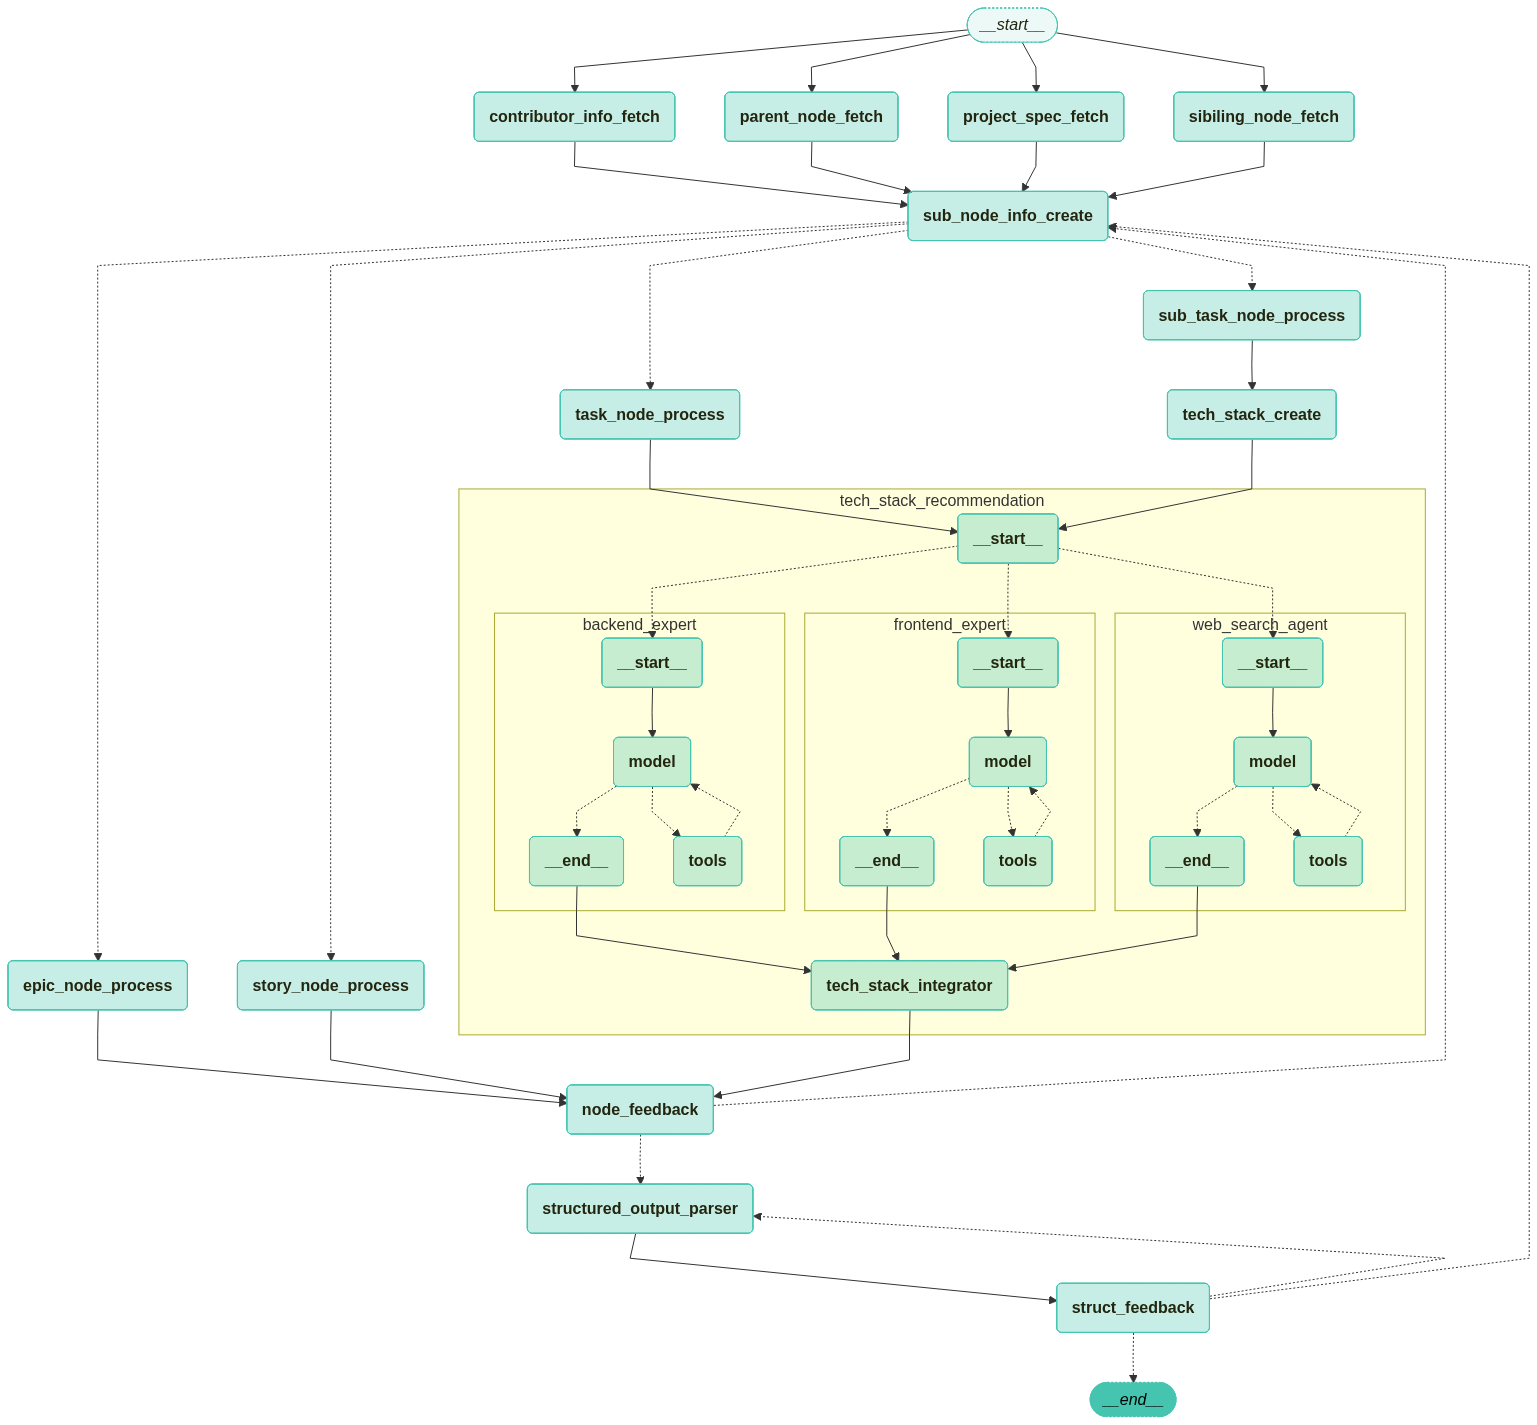

In [64]:
from langchain_teddynote.graphs import visualize_graph
graph = builder.compile()
visualize_graph(graph, xray=True)